In [18]:
corr_matrix = np.array([
    [1.0, 0.8, 0.5, 0.8, 0.8, 0.4, 0.3, 0.8, 0.2, 0.3, 0.8, 0.4],
    [0.8, 1.0, 0.8, 0.8, 0.6, 0.8, 0.5, 0.5, 0.3, 0.5, 0.7, 0.6],
    [0.5, 0.8, 1.0, 0.8, 0.7, 0.6, 0.8, 0.7, 0.4, 0.7, 0.8, 0.7],
    [0.8, 0.8, 0.8, 1.0, 0.4, 0.3, 0.3, 0.8, 0.2, 0.3, 0.6, 0.5],
    [0.8, 0.6, 0.7, 0.4, 1.0, 0.5, 0.7, 0.6, 0.2, 0.8, 0.7, 0.5],
    [0.4, 0.8, 0.6, 0.3, 0.5, 1.0, 0.7, 0.7, 0.3, 0.8, 0.6, 0.6],
    [0.3, 0.5, 0.8, 0.3, 0.7, 0.7, 1.0, 0.6, 0.8, 0.6, 0.5, 0.6],
    [0.8, 0.5, 0.7, 0.8, 0.6, 0.7, 0.6, 1.0, 0.4, 0.8, 0.6, 0.8],
    [0.2, 0.3, 0.4, 0.2, 0.2, 0.3, 0.8, 0.4, 1.0, 0.5, 0.3, 0.6],
    [0.3, 0.5, 0.7, 0.3, 0.8, 0.8, 0.6, 0.8, 0.5, 1.0, 0.6, 0.7],
    [0.8, 0.7, 0.8, 0.6, 0.7, 0.6, 0.5, 0.6, 0.3, 0.6, 1.0, 0.7],
    [0.4, 0.6, 0.7, 0.5, 0.5, 0.6, 0.6, 0.8, 0.6, 0.7, 0.7, 1.0]
])

features = [f"Var{i}" for i in range(corr_matrix.shape[0])]

threshold = 0.5  # Set your desired threshold

# Set values higher than threshold to 1, others to 0
binary_matrix = (corr_matrix > threshold).astype(int)

# anchors_indices = [features.index(feature) for feature in features if feature in anchors_set]
features_indices = [features.index(feature) for feature in features]

result = {
    str(idx): [
        str(i) for i in np.where(binary_matrix[idx] == 1)[0] 
        if i != idx 
    ]
    for idx in features_indices
}
print(result)

{'0': ['1', '3', '4', '7', '10'], '1': ['0', '2', '3', '4', '5', '10', '11'], '2': ['1', '3', '4', '5', '6', '7', '9', '10', '11'], '3': ['0', '1', '2', '7', '10'], '4': ['0', '1', '2', '6', '7', '9', '10'], '5': ['1', '2', '6', '7', '9', '10', '11'], '6': ['2', '4', '5', '7', '8', '9', '11'], '7': ['0', '2', '3', '4', '5', '6', '9', '10', '11'], '8': ['6', '11'], '9': ['2', '4', '5', '6', '7', '10', '11'], '10': ['0', '1', '2', '3', '4', '5', '7', '9', '11'], '11': ['1', '2', '5', '6', '7', '8', '9', '10']}


In [31]:
import numpy as np
import pandas as pd
import networkx as nx

# Giả sử đây là dictionary của bạn
# correlation_dict = {
#     'age': ['income', 'education_level', 'marital_status'],
#     'income': ['age', 'education_level', 'job_type'],
#     'education_level': ['age', 'income', 'job_type'],
#     'marital_status': ['age'],
#     'job_type': ['income', 'education_level']
# }
correlation_dict = result
# --- Sắp xếp các features ---
# Xây dựng đồ thị từ dictionary
# Lưu ý: dictionary của bạn có thể không đối xứng (vd: 'A' trong list của 'B' nhưng 'B' không có trong list của 'A')
# nx.Graph() sẽ tự động xử lý và tạo cạnh đối xứng. Nếu muốn chính xác, dùng nx.DiGraph()
G = nx.Graph(correlation_dict)

# Tính các độ đo trung tâm
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
betweenness_centrality = nx.betweenness_centrality(G)

# Sắp xếp với nhiều tiêu chí phụ
sorted_features = sorted(
    G.nodes(),
    key=lambda f: (
        -degree_centrality[f], 
        # -betweenness_centrality[f],
        -eigenvector_centrality[f], 

        f
    )
)

print("Thứ tự các feature đã được sắp xếp:")
print(sorted_features)
# Kết quả ví dụ: ['education_level', 'income', 'age', 'job_type', 'marital_status']
# (Thứ tự có thể hơi khác tùy vào phiên bản networkx, nhưng logic là nhất quán)

Thứ tự các feature đã được sắp xếp:
['2', '10', '7', '11', '9', '5', '4', '1', '6', '3', '0', '8']


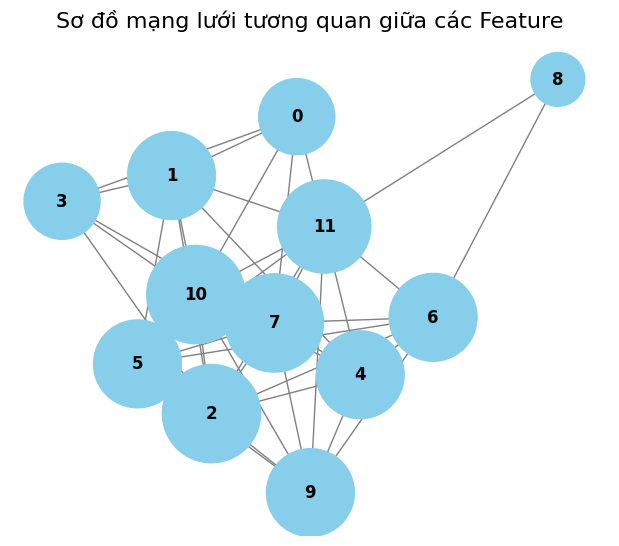

In [28]:
import matplotlib.pyplot as plt
# 3. Tùy chỉnh cho việc vẽ đồ thị
# Tính bậc (số lượng tương quan) của mỗi nút để điều chỉnh kích thước
degrees = [G.degree(node) for node in G.nodes()]

# Tăng kích thước các nút để dễ nhìn hơn
# Bạn có thể điều chỉnh số 500 để đồ thị đẹp hơn với dữ liệu của bạn
node_sizes = [deg * 500 + 500 for deg in degrees]

# Chọn một layout để sắp xếp các nút một cách tự động và đẹp mắt
# spring_layout là một lựa chọn phổ biến
pos = nx.spring_layout(G, seed=42)  # seed=42 để đảm bảo layout không đổi mỗi lần chạy

# 4. Vẽ đồ thị
plt.figure(figsize=(6, 5))  # Tạo một khung hình lớn hơn

nx.draw(G, 
        pos,
        with_labels=True,      # Hiển thị tên của các feature
        node_color='skyblue',  # Màu của các điểm
        node_size=node_sizes,  # Kích thước các điểm tỉ lệ với số tương quan
        edge_color='gray',     # Màu của các đường nối
        font_size=12,          # Cỡ chữ của tên feature
        font_weight='bold')    # In đậm tên feature

# 5. Hiển thị đồ thị
plt.title("Sơ đồ mạng lưới tương quan giữa các Feature", size=16)
plt.show()

In [32]:
# Tạo một map để tra cứu vị trí (index) của mỗi feature một cách nhanh chóng
feature_to_index = {feature: i for i, feature in enumerate(sorted_features)}

num_features = len(sorted_features)
predictor_matrix = np.zeros((num_features, num_features), dtype=int)

# Vòng lặp qua các feature đã sắp xếp để xác định các mối quan hệ
for row_feature in sorted_features:
    # Lấy danh sách các feature tương quan cao với row_feature từ dictionary gốc
    correlated_predictors = correlation_dict.get(row_feature, [])
    
    # Lấy index của feature đang được dự báo (hàng)
    row_idx = feature_to_index[row_feature]
    
    for col_feature in correlated_predictors:
        # Kiểm tra xem feature dự báo (cột) có tồn tại trong danh sách đã sắp xếp không
        if col_feature in feature_to_index:
            col_idx = feature_to_index[col_feature]
            
            # ÁP DỤNG CẢ HAI QUY TẮC:
            # 1. col_idx < row_idx (quy tắc thứ tự)
            # 2. col_feature có trong list tương quan (đã được đảm bảo bởi vòng lặp)
            if col_idx < row_idx:
                predictor_matrix[row_idx, col_idx] = 1

# Chuyển thành Pandas DataFrame để dễ đọc
predictor_df_from_dict = pd.DataFrame(predictor_matrix, 
                                      index=sorted_features, 
                                      columns=sorted_features)

print("\nPredictor Matrix xây dựng từ Dictionary:")
print(predictor_df_from_dict)


Predictor Matrix xây dựng từ Dictionary:
    2  10  7  11  9  5  4  1  6  3  0  8
2   0   0  0   0  0  0  0  0  0  0  0  0
10  1   0  0   0  0  0  0  0  0  0  0  0
7   1   1  0   0  0  0  0  0  0  0  0  0
11  1   1  1   0  0  0  0  0  0  0  0  0
9   1   1  1   1  0  0  0  0  0  0  0  0
5   1   1  1   1  1  0  0  0  0  0  0  0
4   1   1  1   0  1  0  0  0  0  0  0  0
1   1   1  0   1  0  1  1  0  0  0  0  0
6   1   0  1   1  1  1  1  0  0  0  0  0
3   1   1  1   0  0  0  0  1  0  0  0  0
0   0   1  1   0  0  0  1  1  0  1  0  0
8   0   0  0   1  0  0  0  0  1  0  0  0


In [39]:
import networkx as nx
import numpy as np
import time
import platform
import psutil
import datetime
from collections import defaultdict

def monitor_resources(function):
    """Decorator to monitor resources during function execution"""
    def wrapper(*args, **kwargs):
        # Get current time
        current_time = datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')
        print(f"Current Date and Time (UTC - YYYY-MM-DD HH:MM:SS formatted): {current_time}")
        
        # Get user info
        try:
            import getpass
            print(f"Current User's Login: {getpass.getuser()}")
        except:
            print("Could not determine user login")
        
        # Get CPU info
        print(f"CPU: {platform.processor()}")
        print(f"Number of cores: {psutil.cpu_count(logical=False)}")
        print(f"Number of logical processors: {psutil.cpu_count(logical=True)}")
        
        # Memory before execution
        process = psutil.Process()
        memory_before = process.memory_info().rss / (1024 * 1024)
        print(f"Memory usage before execution: {memory_before:.2f} MB")
        
        # Track CPU utilization
        cpu_percent_before = psutil.cpu_percent(percpu=True)
        
        # Execute function
        start_time = time.time()
        result = function(*args, **kwargs)
        execution_time = time.time() - start_time
        
        # CPU utilization during execution
        cpu_percent_after = psutil.cpu_percent(percpu=True)
        cpu_utilized = [i for i, (before, after) in enumerate(zip(cpu_percent_before, cpu_percent_after)) 
                        if after > before + 10]  # +10% threshold for considering a core utilized
        
        # Memory after execution
        memory_after = process.memory_info().rss / (1024 * 1024)
        print(f"Memory usage after execution: {memory_after:.2f} MB")
        print(f"Memory used: {memory_after - memory_before:.2f} MB")
        print(f"Execution time: {execution_time:.2f} seconds")
        print(f"Cores utilized: {len(cpu_utilized)} of {psutil.cpu_count()}")
        
        return result
    return wrapper

@monitor_resources
def order_features_by_centrality(correlation_dict):
    """
    Order features based on their importance in the correlation network.
    
    Args:
        correlation_dict: Dictionary with {feature: [correlated_features]}
    
    Returns:
        List of features in optimal order for Synthpop prediction
    """
    # Create graph
    G = nx.Graph()
    
    # Add all features as nodes first
    all_features = set(correlation_dict.keys())
    for feature_list in correlation_dict.values():
        all_features.update(feature_list)
    
    G.add_nodes_from(all_features)
    
    # Add edges for correlations (undirected graph)
    edge_count = 0
    for feature, correlated_features in correlation_dict.items():
        for corr_feature in correlated_features:
            G.add_edge(feature, corr_feature)
            edge_count += 1
    
    print(f"Graph created with {G.number_of_nodes()} nodes and {edge_count} edges")
    
    # Calculate centrality measures
    try:
        print("Calculating eigenvector centrality...")
        # Eigenvector centrality might not converge with large graphs
        centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-4)
    except nx.PowerIterationFailedConvergence:
        print("Eigenvector centrality failed to converge. Falling back to degree centrality.")
        centrality = nx.degree_centrality(G)
    
    # Create a list of features with their centrality scores
    feature_centrality = [(feature, centrality[feature]) for feature in all_features]
    
    # Calculate degree as secondary sorting criteria
    degrees = dict(G.degree())
    
    # Sort features by centrality (descending), then by degree if centrality is equal
    ordered_features = sorted(
        feature_centrality, 
        key=lambda x: (x[1], degrees[x[0]]), 
        reverse=True
    )
    
    # Extract just the feature names
    ordered_feature_list = [feature for feature, _ in ordered_features]
    
    return ordered_feature_list

@monitor_resources
def create_predictor_matrix(ordered_features):
    """
    Create a binary lower-triangular predictor matrix based on ordered features.
    
    Args:
        ordered_features: List of features in desired order
    
    Returns:
        Binary predictor matrix (numpy array)
    """
    n = len(ordered_features)
    predictor_matrix = np.zeros((n, n), dtype=int)
    
    # Fill the lower triangular part with 1s
    for i in range(1, n):
        predictor_matrix[i, 0:i] = 1
    
    return predictor_matrix

# Example usage:
if __name__ == "__main__":
    # Small example dictionary
    
    # Order features
    ordered_features = order_features_by_centrality(result)
    print("\nOrdered features:", ordered_features)
    
    # Create predictor matrix
    predictor_matrix = create_predictor_matrix(ordered_features)


Current Date and Time (UTC - YYYY-MM-DD HH:MM:SS formatted): 2025-10-02 16:35:30
Current User's Login: trinhtc
CPU: x86_64
Number of cores: 48
Number of logical processors: 48
Memory usage before execution: 125.48 MB
Graph created with 12 nodes and 82 edges
Calculating eigenvector centrality...
Memory usage after execution: 125.48 MB
Memory used: 0.00 MB
Execution time: 0.00 seconds
Cores utilized: 0 of 48

Ordered features: ['2', '10', '7', '11', '9', '5', '4', '1', '6', '3', '0', '8']
Current Date and Time (UTC - YYYY-MM-DD HH:MM:SS formatted): 2025-10-02 16:35:30
Current User's Login: trinhtc
CPU: x86_64
Number of cores: 48
Number of logical processors: 48
Memory usage before execution: 125.48 MB
Memory usage after execution: 125.48 MB
Memory used: 0.00 MB
Execution time: 0.00 seconds
Cores utilized: 0 of 48


In [35]:
pip install memory_profiler

Note: you may need to restart the kernel to use updated packages.
